In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
#Step 1 - load the data
DATA = Path("../results/cox")

emt_scores = pd.read_csv(DATA/"cox_input_emt_only.tsv", sep="\t", index_col=0)
cox_output = pd.read_csv(DATA/"cox_emt_summary.tsv", sep="\t", index_col=0)

print("EMT scores:", emt_scores.shape)
print("Cox proportional hazards model output:", cox_output)

EMT scores: (291, 3)
Cox proportional hazards model output:                coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                                  
EMT        0.279412   1.322353  0.114696        0.054612        0.504213   

           exp(coef) lower 95%  exp(coef) upper 95%  cmp to         z  \
covariate                                                               
EMT                   1.056131             1.655681     0.0  2.436112   

                  p  -log2(p)  
covariate                      
EMT        0.014846  6.073775  


In [3]:
emt_scores.head()

,time_days,event,EMT
5c8c8a6e-40d4-4f82-ac3d-90cfdee15c0a,1263.0,0,0.985496
d9096909-1439-462d-b69c-cad1bf4f420c,940.0,0,-0.172502
29c17355-d646-48da-9e54-7b6dd85dd610,954.0,0,1.703241
29bcba51-2580-473d-9cf7-bedbd0dbad1b,442.0,1,0.521705
ad97b334-e034-4d33-a4d5-48c32d5d521c,2859.0,1,0.429816


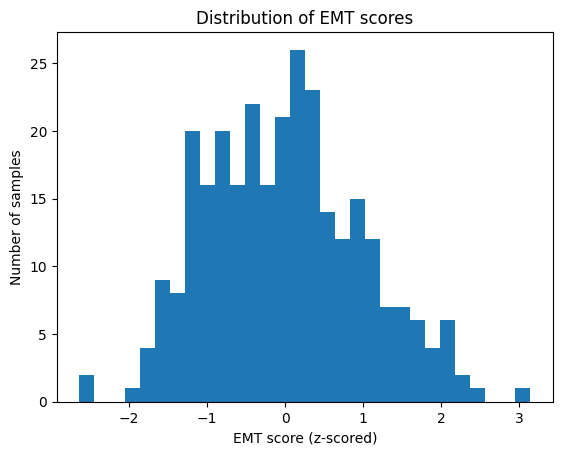

In [4]:
#Step 1 - EMT score distribution
plt.hist(emt_scores["EMT"], bins=30)
plt.xlabel("EMT score (z-scored)")
plt.ylabel("Number of samples")
plt.title("Distribution of EMT scores")
plt.show()

/tmp/ipykernel_45753/1037899172.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


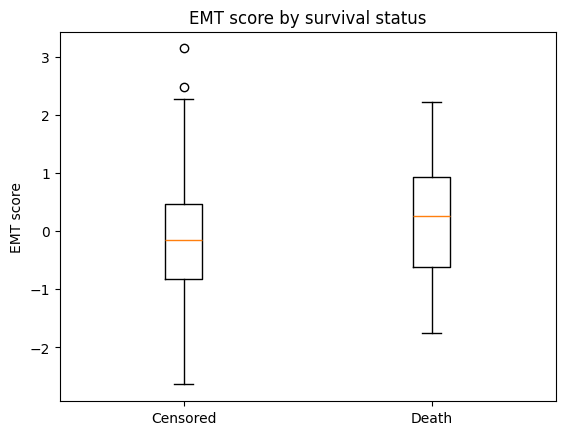

In [5]:
#Step 2 - EMT vs event status
plt.boxplot(
    [emt_scores.loc[emt_scores["event"] == 0, "EMT"],
     emt_scores.loc[emt_scores["event"] == 1, "EMT"]],
    labels=["Censored", "Death"]
)
plt.ylabel("EMT score")
plt.title("EMT score by survival status")
plt.show()


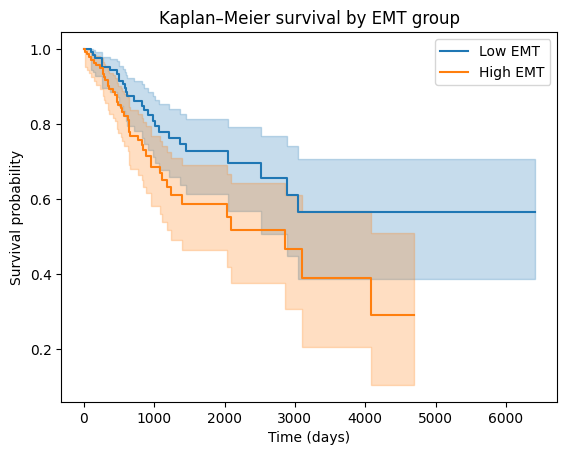

In [6]:
#Step 3 - Kaplan-Meier survival curves
from lifelines import KaplanMeierFitter

emt_scores["EMT_group"] = emt_scores["EMT"] > emt_scores["EMT"].median()

kmf = KaplanMeierFitter()

plt.figure()
for label, g in emt_scores.groupby("EMT_group"):
  kmf.fit(g["time_days"], g["event"],
          label="High EMT" if label else "Low EMT")
  kmf.plot_survival_function()

plt.xlabel("Time (days)")
plt.ylabel("Survival probability")
plt.title("Kaplan–Meier survival by EMT group")
plt.show()

In [7]:
#Step 4 - Log-rank test
from lifelines.statistics import logrank_test

high = emt_scores[emt_scores["EMT_group"]]
low = emt_scores[~emt_scores["EMT_group"]]

lr = logrank_test(
  high["time_days"], low["time_days"],
  event_observed_A=high["event"],
  event_observed_B=low["event"]
)

lr.p_value

np.float64(0.015550345040449129)

In [8]:
OUT = Path("../results/figures_and_log_rank")
OUT.mkdir(exist_ok=True)

with open(OUT / "log_rank.txt", "w") as f:
    f.write(f"Log-rank test p-value: {lr.p_value}")

In [ ]:
# Visualisation of the leading-edge genes of GSEA

df = pd.read_csv("/home/annettestomakhin/Magistritöö/R_scripts_dea_gsea/results/gsea/Supplementary_Table_S4_leading_genes.csv", index_col=0)


In [3]:
df_sorted = df.sort_values(by="stat", ascending=True)


In [4]:
df_sorted.head()

,gene,stat
1,CXCL12,-13.151125
2,PDGFRB,-12.898085
3,TGFBR3,-12.645159
4,LAMA2,-12.590465
5,MATN2,-12.480806


In [5]:
top_genes = df_sorted.head(15)

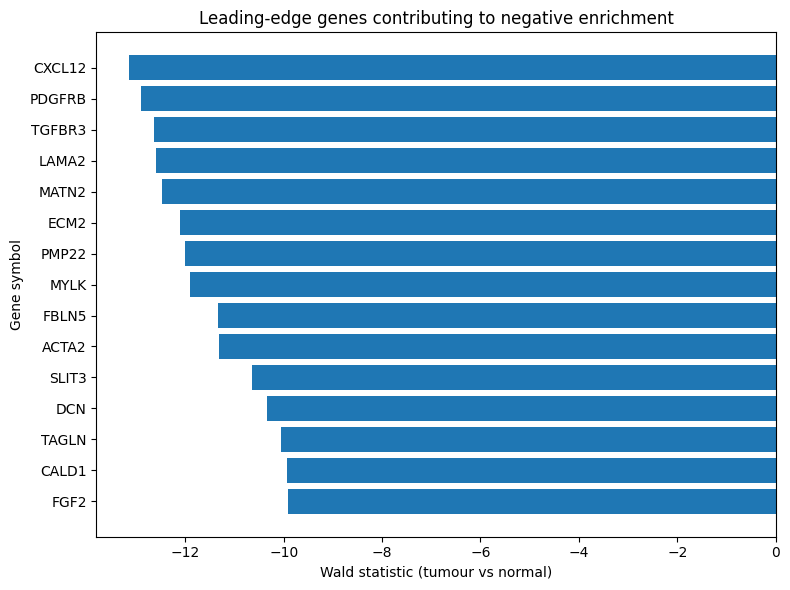

In [6]:
plt.figure(figsize=(8, 6))

bars = plt.barh(top_genes["gene"], top_genes["stat"])

plt.xlabel("Wald statistic (tumour vs normal)")
plt.ylabel("Gene symbol")
plt.title("Leading-edge genes contributing to negative enrichment")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("leading_edge_barplot.png", dpi=300)
plt.show()

In [9]:
#Boxplots for EMT score by FIGO stage and EMT score by lymph node mestastasis status

DATA = Path("../../R_scripts_dea_gsea/results/files_for_python")

patient_metadata = pd.read_csv(DATA/"tcga_meta_01.tsv", sep="\t", index_col=0)

DATA2 = Path("../results/cox")

emt_scores = pd.read_csv(DATA2/"cox_input_emt_only.tsv", sep="\t", index_col=0)

In [10]:
for col in patient_metadata.columns:
  if any(x in col.lower() for x in ["figo", "stage", "lymph"]):
    print(col)

tcga.gdc_cases.diagnoses.tumor_stage
tcga.cgc_case_clinical_stage
tcga.cgc_case_pathologic_stage
tcga.cgc_slide_percent_lymphocyte_infiltration
tcga.xml_primary_lymph_node_presentation_assessment
tcga.xml_lymph_node_examined_count
tcga.xml_number_of_lymphnodes_positive_by_he
tcga.xml_number_of_lymphnodes_positive_by_ihc
tcga.xml_stage_event_system_version
tcga.xml_stage_event_clinical_stage
tcga.xml_stage_event_pathologic_stage
tcga.xml_stage_event_tnm_categories
tcga.xml_stage_event_psa
tcga.xml_stage_event_gleason_grading
tcga.xml_stage_event_ann_arbor
tcga.xml_stage_event_serum_markers
tcga.xml_stage_event_igcccg_stage
tcga.xml_stage_event_masaoka_stage
tcga.xml_lymphatic_invasion
tcga.xml_number_of_lymphnodes_positive
tcga.xml_primary_pathology_primary_lymph_node_presentation_assessment
tcga.xml_primary_pathology_lymph_node_examined_count
tcga.xml_primary_pathology_number_of_lymphnodes_positive_by_he
tcga.xml_lymph_node_location_positive_pathology_names
tcga.xml_lymph_node_location

In [11]:
print(patient_metadata["tcga.cgc_case_clinical_stage"].head(20))

5c8c8a6e-40d4-4f82-ac3d-90cfdee15c0a      Stage IB
d9096909-1439-462d-b69c-cad1bf4f420c      Stage II
29c17355-d646-48da-9e54-7b6dd85dd610      Stage IB
29bcba51-2580-473d-9cf7-bedbd0dbad1b    Stage IIIB
ad97b334-e034-4d33-a4d5-48c32d5d521c     Stage IB1
99d84d46-19da-43f1-b639-dce9953f1529     Stage IB1
6ec25686-4547-459c-9e01-7edf8daece35     Stage IB1
6bca24e6-440f-42c5-abe5-66c37b713a39       Stage I
dd51c17c-300f-44a4-955a-c9bc85417842      Stage IB
78c26a05-2084-494d-83d3-c52c1b800f4c     Stage IB2
d365a238-4739-4b54-9608-dc548f21c04e     Stage IB1
d587a993-3c47-4d4c-b744-59169d4f7451       Stage I
ba732ed4-f6ba-404e-ba3c-ca558fad866a     Stage IVA
b2088466-fa5d-491c-9982-99b33683e66f      Stage IB
2b5dd791-7692-4721-9519-7d7d49b52570     Stage IIB
6752eed9-7990-433f-a206-d5398c396471           NaN
f941890e-ab33-478f-8c97-1c785dd9428f     Stage IIB
c1411cda-814d-4e21-8929-c0f77858828f     Stage IIB
ef357c46-5c3c-4f51-9383-ff7694d07b97     Stage IB1
aaae0bd9-63fc-4a0e-a27e-447b634

In [12]:
print(patient_metadata["tcga.xml_primary_lymph_node_presentation_assessment"].head(20))

5c8c8a6e-40d4-4f82-ac3d-90cfdee15c0a    YES
d9096909-1439-462d-b69c-cad1bf4f420c    YES
29c17355-d646-48da-9e54-7b6dd85dd610    YES
29bcba51-2580-473d-9cf7-bedbd0dbad1b    NaN
ad97b334-e034-4d33-a4d5-48c32d5d521c    YES
99d84d46-19da-43f1-b639-dce9953f1529    YES
6ec25686-4547-459c-9e01-7edf8daece35    YES
6bca24e6-440f-42c5-abe5-66c37b713a39     NO
dd51c17c-300f-44a4-955a-c9bc85417842    YES
78c26a05-2084-494d-83d3-c52c1b800f4c    YES
d365a238-4739-4b54-9608-dc548f21c04e    YES
d587a993-3c47-4d4c-b744-59169d4f7451     NO
ba732ed4-f6ba-404e-ba3c-ca558fad866a    NaN
b2088466-fa5d-491c-9982-99b33683e66f    YES
2b5dd791-7692-4721-9519-7d7d49b52570    NaN
6752eed9-7990-433f-a206-d5398c396471     NO
f941890e-ab33-478f-8c97-1c785dd9428f    YES
c1411cda-814d-4e21-8929-c0f77858828f    NaN
ef357c46-5c3c-4f51-9383-ff7694d07b97    YES
aaae0bd9-63fc-4a0e-a27e-447b634bad99    YES
Name: tcga.xml_primary_lymph_node_presentation_assessment, dtype: object


In [13]:
df = emt_scores.merge(patient_metadata[["tcga.cgc_case_clinical_stage"]], left_index=True, right_index=True, how="left")



In [14]:
df.shape

(291, 4)

In [15]:
df.isna().sum()

time_days                       0
event                           0
EMT                             0
tcga.cgc_case_clinical_stage    6
dtype: int64

In [16]:
df = df.dropna(subset=["tcga.cgc_case_clinical_stage"])

In [17]:
df.shape
df["tcga.cgc_case_clinical_stage"].isna().sum()

np.int64(0)

In [18]:
df["FIGO_group"] = df["tcga.cgc_case_clinical_stage"].str.extract(r"Stage\s*([IVX]+)")

In [19]:
df["FIGO_group"].value_counts()

FIGO_group
I      159
II      64
III     41
IV      21
Name: count, dtype: int64

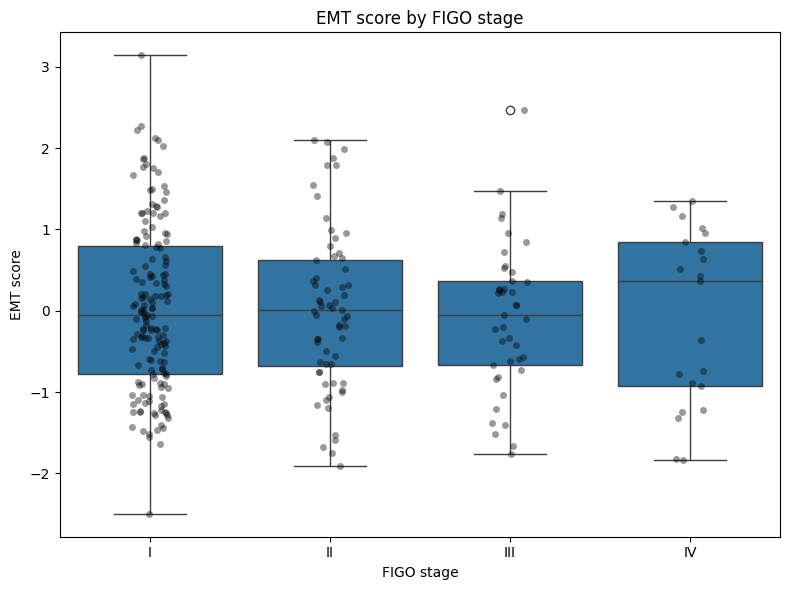

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.boxplot(data=df, x="FIGO_group", y="EMT")
sns.stripplot(data=df, x="FIGO_group", y="EMT", color="black", alpha=0.4)

plt.xlabel("FIGO stage")
plt.ylabel("EMT score")
plt.title("EMT score by FIGO stage")

plt.tight_layout()
plt.savefig("emt_by_figo.png", dpi=300)
plt.show()

In [21]:
from scipy.stats import kruskal

groups = [group["EMT"].values for _, group in df.groupby("FIGO_group")]

stat, p = kruskal(*groups)

print("Kruskal-Wallis p-value:", p)

Kruskal-Wallis p-value: 0.9571639177423731


In [22]:
df.columns

Index(['time_days', 'event', 'EMT', 'tcga.cgc_case_clinical_stage',
       'FIGO_group'],
      dtype='object')

In [23]:
OUT = Path("../results/cox")
OUT.mkdir(exist_ok=True)

df.to_csv(OUT/"cox3_input.tsv", sep="\t")